# Topics Comparison

Notebook for comparing `S3`, `FASTopic`, and a `TF-IDF` baseline on canonical Polymarket markets. The default text view is `full_description`, but every detector also supports `question` and `question_plus_full_description`.

In [2]:
from polymarket_research import PolymarketDataset
from polymarket_research.data.canonical import CanonicalDatasetBuilder
from polymarket_research.data.raw import RawExternalCovariates
from polymarket_research.utils import setup_root

from polymarket_research.research.topics_detector import (
    FASTopicDetector,
    S3TopicsDetector,
    TFIDFTopicBaseline,
    build_topic_input_frame,
    compare_topic_models,
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', None)
%matplotlib inline

In [3]:
REPO_ROOT = setup_root()
CANONICAL_CACHE_DIR = REPO_ROOT / "research_notebooks" / "running_artefacts_new" / "canonical_dataset"

if (CANONICAL_CACHE_DIR / "markets.parquet").exists():
    from polymarket_research.data.canonical import CanonicalDataset
    canonical = CanonicalDataset.from_parquet(CANONICAL_CACHE_DIR)
    print("Loaded canonical from parquet cache:", CANONICAL_CACHE_DIR)
else:
    raw_dataset = PolymarketDataset()
    raw_dataset.load(include_raw_trades=False)
    raw_external = RawExternalCovariates().load()
    canonical = CanonicalDatasetBuilder(
        raw_dataset=raw_dataset,
        raw_external=raw_external,
        resolved_only=True,
    ).build()
    print("Built canonical from SQLite")

all_markets = canonical.markets.copy()
probabilities = canonical.probabilities.copy()
print(f"Canonical resolved markets: {len(all_markets)}")
display(all_markets[["market_id", "question", "domain", "family_id", "volume_num"]].head(5))

Loaded canonical from parquet cache: /Users/sneddy/research/polymarket_research/research_notebooks/running_artefacts_new/canonical_dataset
Canonical resolved markets: 15662


,market_id,question,domain,family_id,volume_num
0,1914442,"Will Hegseth say ""AI"" or ""Cyber"" during press conference?",unassigned,unassigned::::hegseth say ai or cyber during,38222.744674
1,1912772,"Trump announces US x Iran ceasefire end by April 8, 2026?",unassigned,unassigned::::trump announces us x iran ceasefire,38220.348645
2,1908626,Trump announces Hormuz deadline extension today?,unassigned,unassigned::::trump announces hormuz deadline extension today,987122.280619
3,1891746,"Will Trump say ""Strait"" or ""Hormuz"" during events with Rutte?",unassigned,unassigned::::trump say strait or hormuz during,27053.816874
4,1882888,Will Trump's remarks not air?,unassigned,unassigned::::trump s remarks not air,33098.189315


In [4]:
topic_markets = build_topic_input_frame(all_markets)
topic_markets["question_len"] = topic_markets["question"].fillna("").str.len()
topic_markets["full_description_len"] = topic_markets["full_description"].fillna("").str.len()

coverage = pd.DataFrame({
    "n_rows": [len(topic_markets)],
    "nonempty_question": [int(topic_markets["question"].fillna("").str.strip().ne("").sum())],
    "nonempty_full_description": [int(topic_markets["full_description"].fillna("").str.strip().ne("").sum())],
    "mean_question_len": [float(topic_markets["question_len"].mean())],
    "mean_full_description_len": [float(topic_markets["full_description_len"].mean())],
})
display(coverage)
display(topic_markets[["market_id", "question", "full_description", "volume_num"]].head(10))

,n_rows,nonempty_question,nonempty_full_description,mean_question_len,mean_full_description_len
0,15662,15662,15662,57.048206,925.017558


,market_id,question,full_description,volume_num
0,1914442,"Will Hegseth say ""AI"" or ""Cyber"" during press conference?","Pete Hegseth is scheduled to participate in a press conference at 8AM ET on April 8, 2026. (https://x.com/deptofwar/status/2041669612824072473). This market will resolve to ""Yes"" if Pete Hegseth says the listed term during the press conference scheduled for April 8, 2026 at 8AM ET. Otherwise, the market will resolve to ""No"". Plural and possessive forms of the listed term will count toward the resolution of this market regardless of context; however, other forms will NOT count. Instances where the term is used in a compound word will count regardless of context (e.g., joyful is not a compound word for ""joy,"" however, ""killjoy"" is a compounding of the words ""kill"" and ""joy""). This market is explicitly about Hegseth's remarks at the press conference scheduled for 8AM ET on April 8, 2026. (See: https://x.com/deptofwar/status/2041669612824072473). Speeches, events, or comments that occur outside of the named, scheduled event will not qualify toward this market's resolution. If the event contains a Q&A, it will count toward the resolution of this market. AI-generated audio or video will not count toward this market's resolution. If this event is definitively cancelled, or otherwise is not aired by April 8, 2026, 11:59 PM ET, ""-No Qualifying Event-"" will resolve to ""Yes"" and all other brackets will resolve to ""No"". The resolution source will be video of the events. Only remarks which are broadcast or streamed live will count toward this market's resolution. What will Hegseth say during press conference on April 8?",38222.744674
1,1912772,"Trump announces US x Iran ceasefire end by April 8, 2026?","On April 7–8, 2026, the United States and Iran agreed to a temporary two-week ceasefire aimed at halting direct hostilities and de-escalating the ongoing conflict. This market will resolve to ""Yes"" if President Trump, the US government, or the US military publicly and officially announces that the ceasefire between the United States and Iran has ended or is no longer in effect by the specified date, 11:59 PM ET. Otherwise, this market will resolve to ""No."" Qualifying statements must explicitly indicate that the ceasefire between the United States and Iran has ended, been terminated, or is no longer in effect, or use equivalently definitive language clearly signaling the end of the ceasefire commitment. Statements that merely reference violations, breaches, or non-compliance with the ceasefire, without an explicit declaration that the US is no longer committed to the ceasefire, will not alone qualify. Announcements of a new agreement (e.g, a broader peace framework) that supersedes the initial ceasefire agreement while maintaining a halt in direct military engagement between the United States and Iran will not qualify; only announcements that explicitly terminate the commitment to refrain from military hostilities will qualify. Informal announcements, statements from unnamed sources, or leaks do not qualify. Written public statements from Donald Trump (e.g., posts from his personal Truth Social account) will qualify. Videos posted on his social media accounts will also qualify for a ""Yes"" resolution. The primary resolution source for this market will be official statements from the US government and/or its official representatives; however, a consensus of credible reporting may also be used. Note: this market will resolve solely based on whether a qualifying announcement is made within the specified timeframe. Whether the ceasefire actually ends in practice or whether hostilities resume will not be considered. Trump announces US x Iran ceasefire end by...?",38220.348645
2,1908626,Trump announces Hormuz deadline extension today?,"Donald Trump announced a deadline for Iran to open the Strait of Hormuz of Tuesday, April 7, 2026, at 8:00 PM ET (see: https://www.nytimes.com/2026/04/06/world/middleeast/

## Run Config

Use `TEXT_MODE = "full_description"` for the description-centric view. Switch to `"question"` or `"question_plus_full_description"` to compare text views.

In [5]:
TEXT_MODE = "full_description"
N_TOPICS = 12
MIN_DF = 5
MAX_DF = 0.5
TOP_TERMS = 8
FASTOPIC_EPOCHS = 60
SAMPLE_SIZE = None
SORT_BY = "volume_num"
REDUCERS = ["umap", "tsne"]

work_markets = topic_markets.copy()
work_markets = work_markets.loc[work_markets[TEXT_MODE].fillna("").astype(str).str.strip().ne("")].copy()
if SORT_BY in work_markets.columns:
    work_markets = work_markets.sort_values(SORT_BY, ascending=False, kind="stable")
if SAMPLE_SIZE is not None:
    work_markets = work_markets.head(int(SAMPLE_SIZE)).copy()

print("Rows used for modeling:", len(work_markets))
display(work_markets[["market_id", "question", "full_description", "volume_num"]].head(5))

Rows used for modeling: 15662


,market_id,question,full_description,volume_num
10885,546814,Will Zelenskyy wear a suit before July?,"This market will resolve to ""Yes"" if Volodymyr Zelenskyy is is photographed or videotaped wearing a suit between May 22 and June 30, 2025 ET. Otherwise, this market will resolve to ""No"". For this market to resolve to ""Yes"" the images or video must be taken and released within this market's timeframe. The images or video must be authentic, not the result of artificial intelligence or video editing. The resolution source will be a consensus of credible reporting. Will Zelenskyy wear a suit before July?",2.422312e+08
7535,601697,Fed decreases interest rates by 50+ bps after January 2026 meeting?,"The FED interest rates are defined in this market by the upper bound of the target federal funds range. The decisions on the target federal fund range are made by the Federal Open Market Committee (FOMC) meetings. This market will resolve to the amount of basis points the upper bound of the target federal funds rate is changed by versus the level it was prior to the Federal Reserve's January 2026 meeting. If the target federal funds rate is changed to a level not expressed in the displayed options, the change will be rounded up to the nearest 25 and will resolve to the relevant bracket. (e.g. if there's a cut/increase of 12.5 bps it will be considered to be 25 bps) The resolution source for this market is the FOMC’s statement after its meeting scheduled for January 27 - 28, 2026 according to the official calendar: https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm. The level and change of the target federal funds rate is also published at the official website of the Federal Reserve at https://www.federalreserve.gov/monetarypolicy/openmarket.htm. This market may resolve as soon as the FOMC’s statement for their January meeting with relevant data is issued. If no statement is released by the end date of the next scheduled meeting, this market will resolve to the ""No change"" bracket. Fed decision in January?",2.350652e+08
7532,601700,Fed increases interest rates by 25+ bps after January 2026 meeting?,"The FED interest rates are defined in this market by the upper bound of the target federal funds range. The decisions on the target federal fund range are made by the Federal Open Market Committee (FOMC) meetings. This market will resolve to the amount of basis points the upper bound of the target federal funds rate is changed by versus the level it was prior to the Federal Reserve's January 2026 meeting. If the target federal funds rate is changed to a level not expressed in the displayed options, the change will be rounded up to the nearest 25 and will resolve to the relevant bracket. (e.g. if there's a cut/increase of 12.5 bps it will be considered to be 25 bps) The resolution source for this market is the FOMC’s statement after its meeting scheduled for January 27 - 28, 2026 according to the official calendar: https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm. The level and change of the target federal funds rate is also published at the official website of the Federal Reserve at https://www.federalreserve.gov/monetarypolicy/openmarket.htm. This market may resolve as soon as the FOMC’s statement for their January meeting with relevant data is issued. If no statement is released by the end date of the next scheduled meeting, this market will resolve to the ""No change"" bracket. Fed decision in January?",2.164557e+08
5856,654415,Will the Fed increase interest rates by 25+ bps after the March 2026 meeting?,"The FED interest rates are defined in this market by the upper bound of the target federal funds range. The decisions on the target federal fund range are made by the Federal Open Market Committee (FOMC) meetings. This market will resolve to the amount of basis points the upper bound of the target federal funds rate is changed by versus the level it was prior to the Federal Reserve's March 2026 meeting. 

In [6]:
detectors = [
    S3TopicsDetector(
        n_topics=N_TOPICS,
        text_mode=TEXT_MODE,
        min_df=MIN_DF,
        max_df=MAX_DF,
        top_terms=TOP_TERMS,
    ),
    FASTopicDetector(
        n_topics=N_TOPICS,
        text_mode=TEXT_MODE,
        min_df=MIN_DF,
        max_df=MAX_DF,
        top_terms=TOP_TERMS,
        n_epochs=FASTOPIC_EPOCHS,
    ),
    TFIDFTopicBaseline(
        n_topics=N_TOPICS,
        text_mode=TEXT_MODE,
        min_df=MIN_DF,
        max_df=MAX_DF,
        top_terms=TOP_TERMS,
    ),
]

results, comparison_summary = compare_topic_models(work_markets, detectors)
display(comparison_summary)

Output()

[16:58:36] Documents encoded.                                                                         ]8;id=902697;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=369838;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#144\144]8;;\

           Decomposition done.                                                                        ]8;id=43736;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=509948;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#151\151]8;;\

[16:58:37] Term extraction done.                                                                      ]8;id=545796;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=128556;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#154\154]8;;\

[16:58:39] Vocabulary encoded.                                                                        ]8;id=28803;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=163827;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#164\164]8;;\

...

Output()

[17:00:30] Documents encoded.                                                                       ]8;id=351945;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/fastopic.py\fastopic.py]8;;\:]8;id=832745;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/fastopic.py#157\157]8;;\

[17:00:31] Term extraction done.                                                                    ]8;id=175967;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/fastopic.py\fastopic.py]8;;\:]8;id=99348;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/fastopic.py#161\161]8;;\

[17:00:46] Model fitting done.                                                                      ]8;id=264695;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/fastopic.py\fastopic.py]8;;\:]8;id=460387;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/fastopic.py#164\164]8;;\

,model_name,text_mode,n_documents,n_topics,runtime_seconds,mean_topic_confidence
0,TFIDF,full_description,15662,12,1.152175,0.116706
1,S3,full_description,15662,12,121.703928,0.508576
2,FASTopic,full_description,15662,12,121.775814,0.224501


In [7]:
for model_name, result in results.items():
    print("=" * 100)
    print(model_name)
    display(result.topic_summary()[["topic_id", "topic_label", "topic_size"]])

S3


,topic_id,topic_label,topic_size
0,4,"topic_4: earnings gaap, quarterly earnings, earnings, earnings non",1921
1,0,"topic_0: prix canceled, grand prix, f1 season, prix",1579
2,5,"topic_5: parliamentary election, parliamentary elections, national election, chilean electoral",1525
3,3,"topic_3: eurovision tv, eurovision 2025, time fifa, footage eurovision",1460
4,10,"topic_10: nyc mayoral, recount, credible sports, certified recount",1460
5,2,"topic_2: israel strikes, israel strike, strike yemen, strike gaza",1441
6,8,"topic_8: 2025 mlb, nfc, super bowl, 2025 winner",1273
7,1,"topic_1: handshake unclear, permitted handshake, non handshake, qualify handshake",1227
8,6,"topic_6: opening weekend, domestically opening, movie numbers, weekend box",1164
9,9,"topic_9: context joyful, words count, pluralization, possessive term",1070


FASTopic


,topic_id,topic_label,topic_size
0,3,"topic_3: election, party, vote, seats",2082
1,5,"topic_5: territory, missiles, military, ground",1742
2,1,"topic_1: tournament, team, player, point impossible",1580
3,0,"topic_0: approval, rating, approval rating, silver bulletin",1449
4,7,"topic_7: unavailable check, whichever, lx, completed game",1297
5,2,"topic_2: weekend, opening, office, weekend box",1286
6,8,"topic_8: minute candle, candle, com en, selected",1231
7,6,"topic_6: counter, views, global, shows",1153
8,10,"topic_10: term, compound, joy, trump",1119
9,9,"topic_9: senate, listed individual, formally, removal",1097


TFIDF


,topic_id,topic_label,topic_size
0,0,"topic_0: trump, consensus credible, reporting, credible reporting",4625
1,11,"topic_11: price, data, binance, netflix",2872
2,7,"topic_7: tournament, winner, player, 2026",1723
3,4,"topic_4: election, party, round, based",1448
4,10,"topic_10: academy, awards, eurovision, prix",971
5,2,"topic_2: count, term, event, trump",967
6,5,"topic_5: strike, missiles, ground, missile",834
7,9,"topic_9: game, fifa, isw, cup",726
8,1,"topic_1: weekend, box office, box, office",583
9,8,"topic_8: leaderboard, arena, ai, arena score",569


/Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


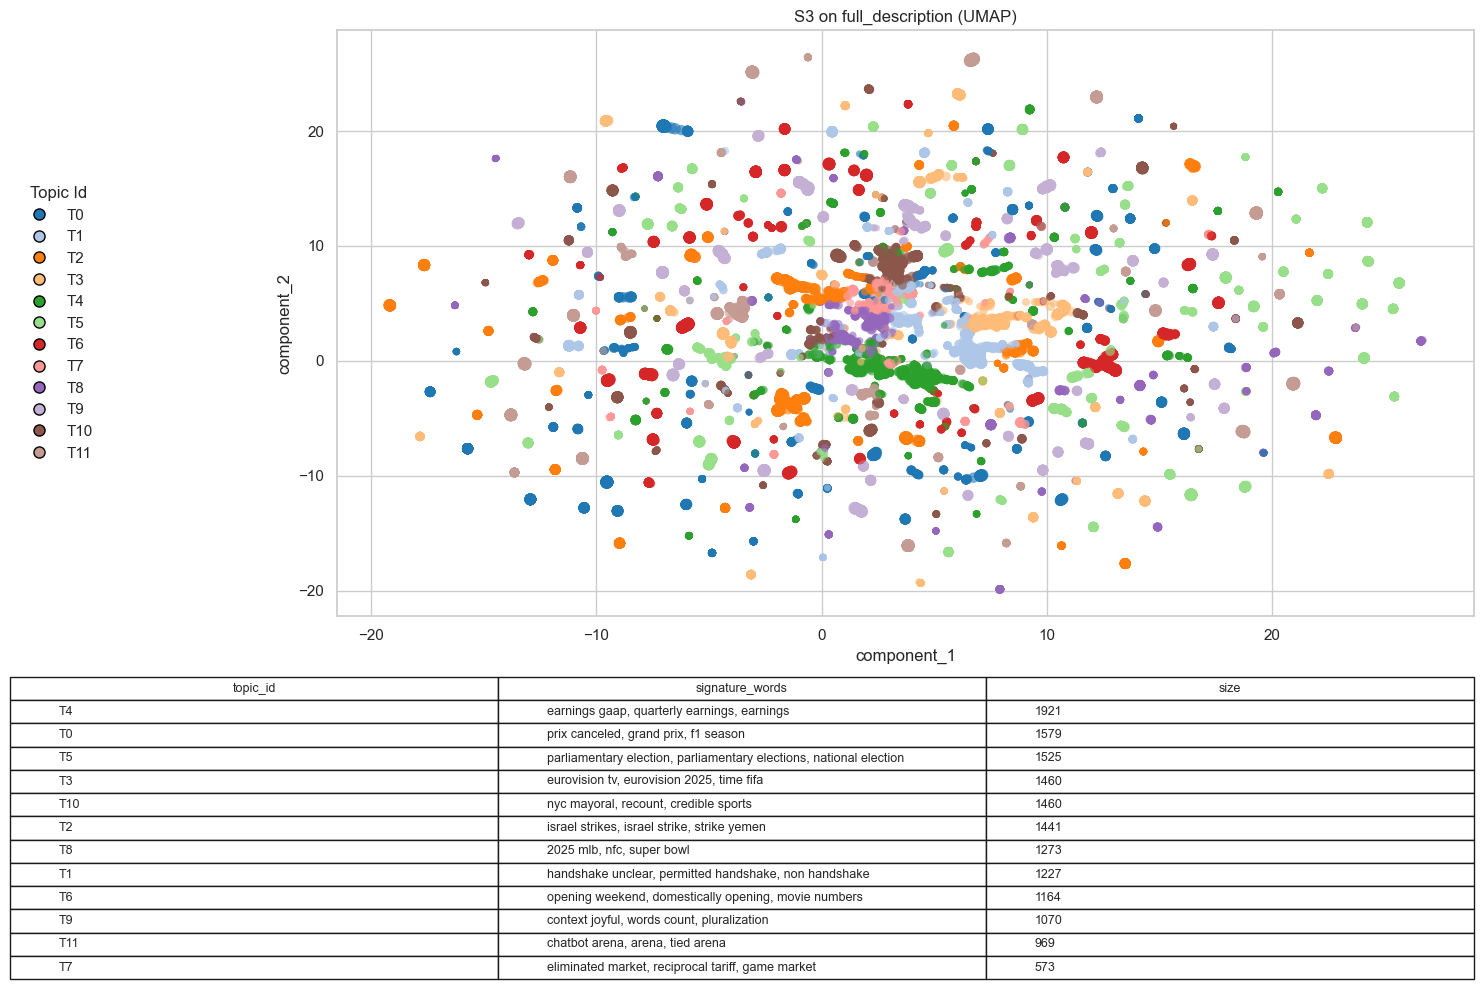

/Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely d

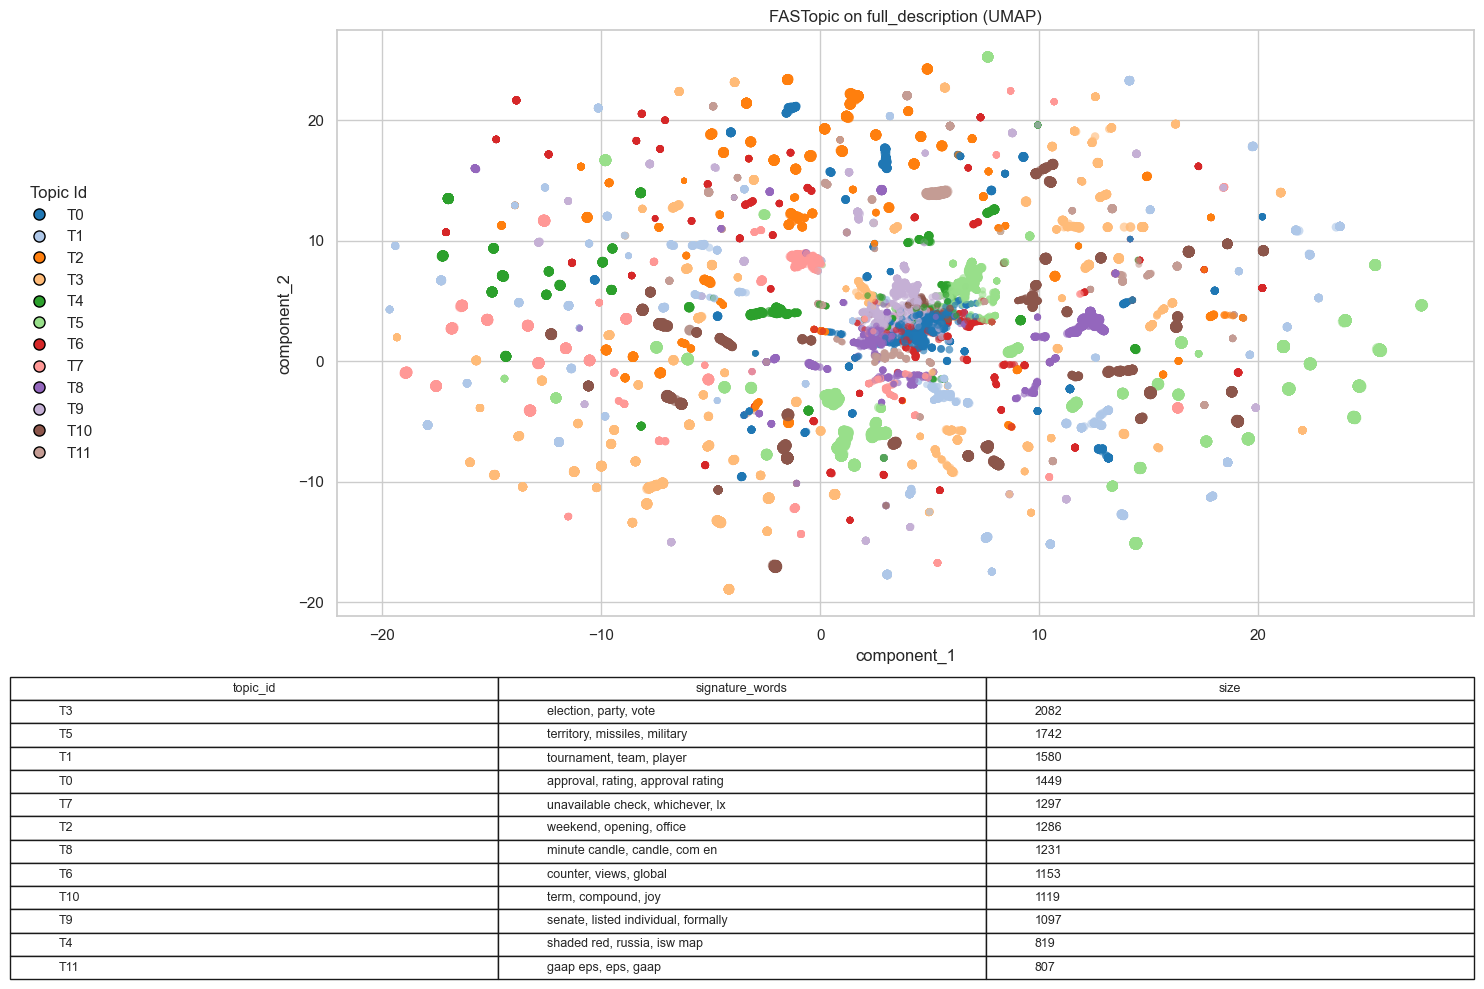

/Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely d

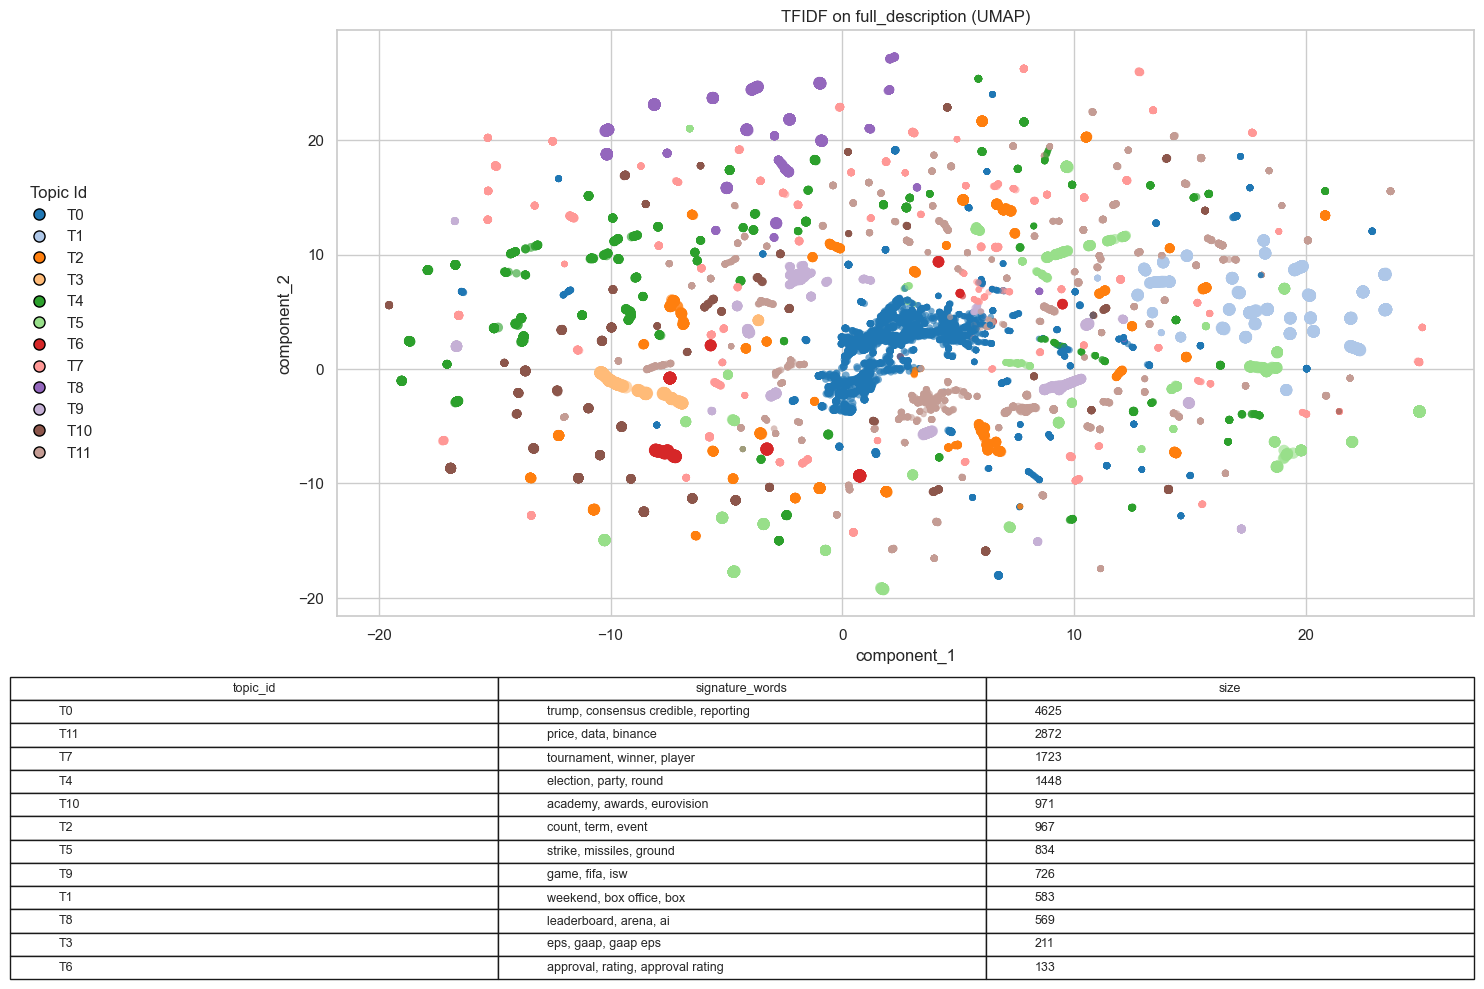

In [8]:
for model_name, result in results.items():
    fig, axes, projected = result.plot_2d_with_topic_map(
        reducer="umap",
        random_state=0,
        table_position="bottom",
        figsize=(15, 10),
    )
    plt.show()

In [9]:
TOP_DOCS_PER_TOPIC = 5
for model_name, result in results.items():
    print("=" * 100)
    print(f"Representative documents for {model_name}")
    display(
        result.representative_documents(top_n=TOP_DOCS_PER_TOPIC)[
            ["market_id", "topic_id", "topic_confidence", "topic_label", "question", "full_description"]
        ]
    )

Representative documents for S3


,market_id,topic_id,topic_confidence,topic_label,question,full_description
0,532894,0,1.000000,"topic_0: prix canceled, grand prix, f1 season, prix",Will global temperature increase by between 1.37-1.41ºC in April 2025?,"This market will resolve to the value reported by the Global Land-Ocean Temperature Index for April 2025 when it is released. Otherwise, this market will resolve to ""No"". An anomaly of a named bracket for April 2025 is necessary and sufficient to resolve this market to ""Yes"" immediately once the data becomes available regardless of whether the figure for April 2025 is later revised. The primary resolution source for this market will be the figure found in the table titled ""GLOBAL Land-Ocean Temperature Index in 0.01 degrees Celsius"" under the column ""Apr"" in the row ""2025"" (https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.txt). If NASA's ""Global Temperature Index"" is rendered permanently unavailable, other information from NASA may be used. If no information for April 2025 is provided by NASA by August 1, 2025, 11:59 PM ET, this market will resolve ""Yes"". April 2025 Temperature Increase (ºC)"
1,954200,0,1.000000,"topic_0: prix canceled, grand prix, f1 season, prix","Will Affirm Holdings (AFRM) be added to the S&P 500 by March 31, 2026?","The S&P 500 undergoes quarterly reconstitution on the third Friday of March, June, September, and December. The next rebalance is currently scheduled for March 20, 2026. This market will resolve to ""Yes"" if S&P Global Inc. announces that the listed company will be added to the S&P 500 index by March 31, 2026, 11:59 PM ET. Otherwise, this market will resolve to ""No."" To qualify, the listed ticker must match the announced ticker added to the index. An announcement from S&P will qualify for a ""Yes"" resolution, regardless of whether the listed company has actually been added to the S&P 500 index by the resolution date. The primary resolution source will be official announcements from S&P Global Inc. (https://www.spglobal.com/en/press/press-release). Which companies added to S&P 500 in Q1 2026?"
2,551430,0,1.000000,"topic_0: prix canceled, grand prix, f1 season, prix",Will global temperature increase by between 1.10-1.14ºC in June 2025?,"This market will resolve to the value reported by the Global Land-Ocean Temperature Index for June 2025 when it is released. Otherwise, this market will resolve to ""No"". An anomaly of a named bracket for June 2025 is necessary and sufficient to resolve this market to ""Yes"" immediately once the data becomes available regardless of whether the figure for June 2025 is later revised. The primary resolution source for this market will be the figure found in the table titled ""GLOBAL Land-Ocean Temperature Index in 0.01 degrees Celsius"" under the column ""Jun"" in the row ""2025"" (https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.txt). If NASA's ""Global Temperature Index"" is rendered permanently unavailable, other information from NASA may be used. If no information for June 2025 is provided by NASA by September 1, 2025, 11:59 PM ET, this market will resolve ""Yes"". June 2025 Temperature Increase (ºC)"
3,532890,0,1.000000,"topic_0: prix canceled, grand prix, f1 season, prix",Will global temperature increase by less than 1.22ºC in April 2025?,"This market will resolve to the value reported by the Global Land-Ocean Temperature Index for April 2025 when it is released. Otherwise, this market will resolve to ""No"". An anomaly of a named bracket for April 2025 is necessary and sufficient to resolve this market to ""Yes"" immediately once the data becomes available regardless of whether the figure for April 2025 is later revised. The primary resolution source for this market will be the figure found in the table titled ""GLOBAL Land-Ocean Temperature Index in 0.01 degrees Celsius"" under the column ""Apr"" in the row ""2025"" (https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.txt). If NASA's ""Global

Representative documents for FASTopic


,market_id,topic_id,topic_confidence,topic_label,question,full_description
0,536445,0,0.280731,"topic_0: approval, rating, approval rating, silver bulletin",Will Trump's approval rating be between 44.0% and 44.9% on April 18?,"This market will resolve according to Silver Bulletin's approval rating for Donald Trump on April 18, 2025. Note that the approval ratings for this date must be finalized before it is considered for this market (namely once the next data point is available, the previous one is finalized). This market's resolution source will be Silver Bulletin' approval rating poll aggregator, https://www.natesilver.net/p/trump-approval-ratings-nate-silver-bulletin, specifically the approval rating indicated by the green trend line for the resolution date. Changes in the methodology by which Silver Bulletin calculates the approval rating will have no bearing on the resolution of this market. If Silver Bulletin's approval rating becomes permanently unavailable, RealClearPolitics will be used. The resolution source reports the rating value to only one decimal point (e.g. 42.8%, 33.9%, etc). Thus, this is the level of precision that will be used when resolving the market. Trump approval rating on April 18?"
1,536443,0,0.280731,"topic_0: approval, rating, approval rating, silver bulletin",Will Trump's approval rating be less than 43.0% on April 18?,"This market will resolve according to Silver Bulletin's approval rating for Donald Trump on April 18, 2025. Note that the approval ratings for this date must be finalized before it is considered for this market (namely once the next data point is available, the previous one is finalized). This market's resolution source will be Silver Bulletin' approval rating poll aggregator, https://www.natesilver.net/p/trump-approval-ratings-nate-silver-bulletin, specifically the approval rating indicated by the green trend line for the resolution date. Changes in the methodology by which Silver Bulletin calculates the approval rating will have no bearing on the resolution of this market. If Silver Bulletin's approval rating becomes permanently unavailable, RealClearPolitics will be used. The resolution source reports the rating value to only one decimal point (e.g. 42.8%, 33.9%, etc). Thus, this is the level of precision that will be used when resolving the market. Trump approval rating on April 18?"
2,536448,0,0.280731,"topic_0: approval, rating, approval rating, silver bulletin",Will Trump's approval rating be 47.0% or higher on April 18?,"This market will resolve according to Silver Bulletin's approval rating for Donald Trump on April 18, 2025. Note that the approval ratings for this date must be finalized before it is considered for this market (namely once the next data point is available, the previous one is finalized). This market's resolution source will be Silver Bulletin' approval rating poll aggregator, https://www.natesilver.net/p/trump-approval-ratings-nate-silver-bulletin, specifically the approval rating indicated by the green trend line for the resolution date. Changes in the methodology by which Silver Bulletin calculates the approval rating will have no bearing on the resolution of this market. If Silver Bulletin's approval rating becomes permanently unavailable, RealClearPolitics will be used. The resolution source reports the rating value to only one decimal point (e.g. 42.8%, 33.9%, etc). Thus, this is the level of precision that will be used when resolving the market. Trump approval rating on April 18?"
3,536446,0,0.280731,"topic_0: approval, rating, approval rating, silver bulletin",Will Trump's approval rating be between 45.0% and 45.9% on April 18?,"This market will resolve according to Silver Bulletin's approval rating for Donald Trump on April 18, 2025. Note that the approval ratings for this date must be finalized before it is considered for this market (namely once the next data point is available, the previous one is finalized). This market's resolution source wi

Representative documents for TFIDF


,market_id,topic_id,topic_confidence,topic_label,question,full_description
0,542365,0,0.118791,"topic_0: trump, consensus credible, reporting, credible reporting","Trump renames Persian Gulf to ""Arabian Gulf"" in May?","This market will resolve to ""Yes"" if Donald Trump publicly announces, that the United States will officially refer to the Persian Gulf as the ""Arabian Gulf"" or ""Gulf of Arabia"" by May 31, 2025, 11:59 PM ET. Otherwise, this market will resolve to ""No"". The primary resolution source for this market will be official information from Donald Trump however, a consensus of credible reporting may also be used. Trump renames Persian Gulf to ""Arabian Gulf"" in May?"
1,588751,0,0.116976,"topic_0: trump, consensus credible, reporting, credible reporting",Will Eric Adams join Trump administration by December 31?,"This market will resolve to ""Yes"" if Donald Trump officially nominates or appoints Eric Adams to his administration by December 31, 2025, 11:59 PM ET. Otherwise, this market will resolve to ""No"". The Trump administration includes individuals formally appointed or nominated by Donald Trump to roles within the U.S. federal government, such as Cabinet members, Executive Office staff, senior policy advisors, ambassadors, or White House staff whose appointments are publicly announced by official government channels. Nominations will qualify even if the individual is not confirmed. The primary resolution source for this market will be official information from the US government; however, a consensus of credible reporting may also be used. Will Eric Adams join Trump administration by December 31?"
2,567267,0,0.115050,"topic_0: trump, consensus credible, reporting, credible reporting",Trump revokes any US citizenship by December 31?,"This market will resolve to ""Yes"" if any full U.S. citizenship is officially rescinded by December 31, 2025, 11:59 PM ET. Otherwise, this market will resolve to ""No"". The primary resolution sources will be information from the government of the United States, however a consensus of credible reporting will also be used. Trump revokes any US citizenship by December 31?"
3,549903,0,0.114266,"topic_0: trump, consensus credible, reporting, credible reporting",Will Elon Musk rejoin the Trump Administration this year?,"This market will resolve to ""Yes"" if Donald Trump officially nominates or appoints Elon Musk to his administration between June 4, and December 31, 2025, 11:59 PM ET. Otherwise, this market will resolve to ""No"". The Trump administration includes individuals formally appointed or nominated by Donald Trump to roles within the U.S. federal government, such as Cabinet members, Executive Office staff, senior policy advisors, ambassadors, or White House staff whose appointments are publicly announced by official government channels. Nominations will qualify even if the individual is not confirmed. The primary resolution source for this market will be official information from the US government, however a consensus of credible reporting may also be used. Will Elon Musk rejoin the Trump Administration this year?"
4,551485,0,0.113933,"topic_0: trump, consensus credible, reporting, credible reporting",Trump criminalizes desecrating the American flag before August?,"This market will resolve to ""Yes"" if Donald Trump signs any bill into law or if the Trump administration takes any action that makes it a criminal offense to burn, desecrate, or otherwise intentionally damage the flag of the United States by July 31, 2025, 11:59 PM ET. Otherwise, this market will resolve to ""No"". Any law or executive action meeting these criteria will count, even if its implementation is immediately halted or delayed by judicial or other actions. This market's primary resolution source will be official information from the Trump administration, however a consensus of credible reporting may also be used. Trump criminalizes desecrating the American flag before August?"
5,600697,1,0.186566,"topi

In [10]:
# Optional: compare question vs description-centric text on S3 only.
question_results, question_summary = compare_topic_models(
    work_markets,
    [
        S3TopicsDetector(n_topics=N_TOPICS, text_mode="question", min_df=MIN_DF, max_df=MAX_DF, top_terms=TOP_TERMS),
        S3TopicsDetector(n_topics=N_TOPICS, text_mode="full_description", min_df=MIN_DF, max_df=MAX_DF, top_terms=TOP_TERMS),
        S3TopicsDetector(n_topics=N_TOPICS, text_mode="question_plus_full_description", min_df=MIN_DF, max_df=MAX_DF, top_terms=TOP_TERMS),
    ],
)
display(question_summary)
for model_name, result in question_results.items():
    print(model_name, result.text_mode)
    display(result.topic_summary()[["topic_id", "topic_label", "topic_size"]].head(10))

Output()

[17:01:42] Documents encoded.                                                                         ]8;id=373894;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=524014;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#144\144]8;;\

[17:01:43] Decomposition done.                                                                        ]8;id=546918;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=662488;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#151\151]8;;\

           Term extraction done.                                                                      ]8;id=476919;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=10581;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#154\154]8;;\

[17:01:44] Vocabulary encoded.                                                                        ]8;id=441556;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=345393;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#164\164]8;;\

...

[17:05:50] Vocabulary encoded.                                                                        ]8;id=26787;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=361210;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#164\164]8;;\

           Model fitting done.                                                                        ]8;id=435169;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py\decomp.py]8;;\:]8;id=143100;file:///Users/sneddy/anaconda3/envs/polymarket/lib/python3.14/site-packages/turftopic/models/decomp.py#184\184]8;;\

,model_name,text_mode,n_documents,n_topics,runtime_seconds,mean_topic_confidence
0,S3,question,15662,12,12.751314,0.393874
1,S3,full_description,15662,12,109.084187,0.508576
2,S3,question_plus_full_description,15662,12,124.770288,0.385777


S3 question_plus_full_description


,topic_id,topic_label,topic_size
0,3,"topic_3: player win, individual wins, winner determined, player wins",2015
1,2,"topic_2: jeffrey epstein, credible media, net trump, elon musk",1778
2,4,"topic_4: eurovision 2025, global netflix, france 2025, 2025 french",1748
3,5,"topic_5: foreign multilateral, tariffs imports, trump government, tariff imports",1601
4,11,"topic_11: portugal presidential, romanian presidential, president romania, chile presidential",1458
5,6,"topic_6: israel strikes, israel strike, strike yemen, strike gaza",1423
6,7,"topic_7: game market, trump market, market yes, session market",1110
7,9,"topic_9: prix scheduled, grand slam, reporting f1, pga tour",1093
8,8,"topic_8: 2025 gross, 2025 canadian, 2025 nyc, 2025 elect",1016
9,10,"topic_10: token actively, locked tokens, tokens, recognized successor",973
